In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

In [2]:
files = [
    "aisdk-2025-05-15.csv",
    "aisdk-2025-05-16.csv",
    "aisdk-2025-05-17.csv",
    "aisdk-2025-05-18.csv"
]

file_list = ", ".join([f"'{f}'" for f in files])

tmpdir = os.path.expanduser("~/duckdb_tmp")
os.makedirs(tmpdir, exist_ok=True)

con = duckdb.connect("ais_work.duckdb")
con.execute(f"SET temp_directory='{tmpdir}';")
con.execute("SET max_temp_directory_size='100GiB';")
con.execute("SET memory_limit='4GiB';")
con.execute("SET threads=1;")
con.execute("SET preserve_insertion_order=false;")

source_sql = f"""
SELECT *
FROM read_csv(
    [{file_list}],
    header = true,
    union_by_name = true,
    delim = ',',
    quote = '"',
    escape = '"',
    null_padding = true,
    strict_mode = false
)
"""

cols_df = con.execute(f"DESCRIBE {source_sql}").fetchdf()
all_cols = cols_df["column_name"].tolist()

group_cols = ['# Timestamp', 'MMSI']
other_cols = [c for c in all_cols if c not in group_cols]

select_parts = ['"# Timestamp"', '"MMSI"']
select_parts += [f'ANY_VALUE("{c}") AS "{c}"' for c in other_cols]

select_sql = ",\n        ".join(select_parts)

query = f"""
COPY (
    SELECT
        {select_sql}
    FROM ({source_sql}) t
    GROUP BY "# Timestamp", MMSI
) TO 'ais_4days_dedup.csv' (HEADER, DELIMITER ',');
"""

con.execute(query)

print("Baigta: sukurtas failas ais_4days_dedup.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baigta: sukurtas failas ais_4days_dedup.csv


In [53]:
import pandas as pd

df = pd.read_csv("ais_4days_dedup.csv")
print(df.shape)
print(df.info())

(46467529, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46467529 entries, 0 to 46467528
Data columns (total 26 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   # Timestamp                     object 
 1   MMSI                            int64  
 2   Type of mobile                  object 
 3   Latitude                        float64
 4   Longitude                       float64
 5   Navigational status             object 
 6   ROT                             float64
 7   SOG                             float64
 8   COG                             float64
 9   Heading                         float64
 10  IMO                             object 
 11  Callsign                        object 
 12  Name                            object 
 13  Ship type                       object 
 14  Cargo type                      object 
 15  Width                           float64
 16  Length                          float64
 17  Type of po

In [54]:
df['MMSI'].nunique()

10525

In [55]:
print(df.shape)

(46467529, 26)


In [56]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('#', '', regex=False)
)
df = df.rename(columns={'_timestamp': 'timestamp'})

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


df = df.drop(columns=['cargo_type'], errors='ignore')
df['ship_type'] = df['ship_type'].str.strip().str.lower()
df = df[df['ship_type'].isin(['cargo', 'tanker'])].copy()

print(df.columns.tolist())

/var/folders/l7/zz2kjwks3lgfb825_3dd3ghc0000gn/T/ipykernel_72406/3025262795.py:10: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


['timestamp', 'mmsi', 'type_of_mobile', 'latitude', 'longitude', 'navigational_status', 'rot', 'sog', 'cog', 'heading', 'imo', 'callsign', 'name', 'ship_type', 'width', 'length', 'type_of_position_fixing_device', 'draught', 'destination', 'eta', 'data_source_type', 'a', 'b', 'c', 'd']


In [57]:
df['mmsi'].nunique()

1669

In [58]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

print(missing)

                                missing_count  missing_pct
rot                                   1029445     8.324047
heading                                257107     2.078956
eta                                    212622     1.719252
cog                                    178978     1.447208
draught                                 91739     0.741797
c                                       71671     0.579529
d                                       62280     0.503593
b                                       14028     0.113430
a                                        8935     0.072248
sog                                       991     0.008013
name                                      741     0.005992
width                                       6     0.000049
length                                      6     0.000049
callsign                                    0     0.000000
mmsi                                        0     0.000000
ship_type                                   0     0.0000

In [59]:
# garbage values
for col in ['type_of_mobile', 'ship_type', 'navigational_status',
            'type_of_position_fixing_device', 'destination']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(20))


--- type_of_mobile ---
type_of_mobile
Class A    12335406
Class B       31716
Name: count, dtype: int64

--- ship_type ---
ship_type
cargo     9100716
tanker    3266406
Name: count, dtype: int64

--- navigational_status ---
navigational_status
Under way using engine        11300358
Moored                          310606
Constrained by her draught      278766
At anchor                       183582
Restricted maneuverability      145655
Unknown value                   130417
Not under command                16387
Aground                           1038
Under way sailing                  313
Name: count, dtype: int64

--- type_of_position_fixing_device ---
type_of_position_fixing_device
GPS                             11454226
Combined GPS/GLONASS              372653
Internal                          337770
Undefined                         193666
GLONASS                             8454
Integrated navigation system         353
Name: count, dtype: int64

--- destination ---
destination
SE

In [60]:
print(df['type_of_mobile'].value_counts(dropna=False))

pd.crosstab(
    df['type_of_mobile'],
    df['sog'].isna(),
    normalize='index'
) * 100

type_of_mobile
Class A    12335406
Class B       31716
Name: count, dtype: int64


sog,False,True
type_of_mobile,,
Class A,99.992226,0.007774
Class B,99.899105,0.100895


In [61]:
df_ship = df[df['type_of_mobile'].isin(['Class A', 'Class B'])].copy()
df_ship.head()

,timestamp,mmsi,type_of_mobile,latitude,longitude,navigational_status,rot,sog,cog,heading,...,length,type_of_position_fixing_device,draught,destination,eta,data_source_type,a,b,c,d
18,2025-05-15 00:00:34,255806341,Class A,55.556733,9.762533,Moored,0.0,0.0,129.2,300.0,...,144.0,GPS,6.6,DK FRC,2025-05-14 16:00:00,AIS,113.0,31.0,10.0,13.0
56,2025-05-15 00:01:39,259017000,Class A,58.152987,10.569477,Under way using engine,0.0,10.0,320.1,330.0,...,90.0,GPS,3.9,KRAGERO,2025-05-15 05:00:00,AIS,83.0,7.0,3.0,11.0
73,2025-05-15 00:02:21,636022397,Class A,57.522008,11.293632,Under way using engine,0.0,11.2,110.0,107.0,...,183.0,GPS,8.2,SKAGEN,2025-05-14 19:00:00,AIS,150.0,33.0,16.0,16.0
80,2025-05-15 00:02:33,566029000,Class A,57.448333,8.646350,Under way using engine,NaN,15.9,66.0,NaN,...,163.0,GPS,9.8,RULED,2025-05-18 07:00:00,AIS,140.0,23.0,24.0,2.0
87,2025-05-15 00:03:00,574005550,Class A,54.704750,12.503178,Under way using engine,0.0,13.0,238.2,238.0,...,243.0,GPS,8.5,SUEZ_EGYPT,2025-05-29 12:00:00,AIS,202.0,41.0,15.0,27.0


In [62]:
df_ship['mmsi'].nunique()

1669

In [63]:
print("Eilučių:", len(df_ship))
print("Unikalių laivų:", df_ship['mmsi'].nunique())

print("\nType of mobile:")
print(df_ship['type_of_mobile'].value_counts())

print("\nShip type:")
print(df_ship['ship_type'].value_counts(dropna=False).head(20))

Eilučių: 12367122
Unikalių laivų: 1669

Type of mobile:
type_of_mobile
Class A    12335406
Class B       31716
Name: count, dtype: int64

Ship type:
ship_type
cargo     9100716
tanker    3266406
Name: count, dtype: int64


In [64]:
name_counts = (
    df_ship.groupby('mmsi')['name']
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

print(name_counts.head(20))

mmsi
205136000    1
275507000    1
305414000    1
305411000    1
305391000    1
305371000    1
305322000    1
305313000    1
305305000    1
305299000    1
305288000    1
305287000    1
305286000    1
305279000    1
305242000    1
305224000    1
305212000    1
305211000    1
305190000    1
305170000    1
Name: name, dtype: int64


In [65]:
name_map = (
    df_ship.dropna(subset=['name'])
    .groupby('mmsi')['name']
    .agg(lambda s: s.value_counts().index[0])
)

missing_before = df_ship['name'].isna().sum()

df_ship['name_filled'] = df_ship['name'].fillna(
    df_ship['mmsi'].map(name_map)
)

missing_after = df_ship['name_filled'].isna().sum()

print("Trūko prieš:", missing_before)
print("Trūko po:", missing_after)

Trūko prieš: 741
Trūko po: 0


In [66]:
invalid_cog = df_ship['cog'].notna() & ~df_ship['cog'].between(0, 360, inclusive='both')
invalid_heading = df_ship['heading'].notna() & ~df_ship['heading'].between(0, 360, inclusive='both')

print("Neteisingų COG:", invalid_cog.sum())
print("Neteisingų heading:", invalid_heading.sum())

Neteisingų COG: 0
Neteisingų heading: 0


In [67]:
df_ship.loc[invalid_cog, 'cog'] = np.nan
df_ship.loc[invalid_heading, 'heading'] = np.nan

In [68]:
df_ship['time_diff_sec'] = (
    df_ship.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

print(df_ship['time_diff_sec'].describe())
print("time_diff <= 0:", (df_ship['time_diff_sec'] <= 0).sum())
print("time_diff < 10 sec:", (df_ship['time_diff_sec'] < 10).sum())
print("time_diff < 1h:", (df_ship['time_diff_sec'] < 3600).sum())
print("time_diff > 1h:", (df_ship['time_diff_sec'] > 3600).sum())

count    1.236545e+07
mean     1.547540e+01
std      3.195640e+04
min     -3.454820e+05
25%      5.700000e+02
50%      1.541000e+03
75%      3.439000e+03
max      3.379450e+05
Name: time_diff_sec, dtype: float64
time_diff <= 0: 364561
time_diff < 10 sec: 394772
time_diff < 1h: 9433356
time_diff > 1h: 2928231


In [69]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = df_ship.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["mmsi", "timestamp"])

df["prev_lat"] = df.groupby("mmsi")["latitude"].shift(1)
df["prev_lon"] = df.groupby("mmsi")["longitude"].shift(1)
df["prev_time"] = df.groupby("mmsi")["timestamp"].shift(1)

df["dt_hours"] = (df["timestamp"] - df["prev_time"]).dt.total_seconds() / 3600
df["dist_km"] = haversine_km(df["prev_lat"], df["prev_lon"], df["latitude"], df["longitude"])
df["speed_kmh_implied"] = df["dist_km"] / df["dt_hours"]
df["speed_knots_implied"] = df["speed_kmh_implied"] / 1.852

max_speed_knots = 60
jump_mask = (df["dt_hours"] > 0) & (df["speed_knots_implied"] > max_speed_knots)
print("Greitų judesių skaičius:", jump_mask.sum())
print(df.loc[jump_mask, ["mmsi", "timestamp", "latitude", "longitude", "dt_hours", "dist_km", "speed_knots_implied"]])

print(df_ship[df_ship["latitude"] >90].shape[0])
print(df_ship[df_ship["latitude"] <-90].shape[0])
print(df_ship[df_ship["longitude"] >180 ].shape[0])
print(df_ship[df_ship["longitude"] <-180 ].shape[0])

print(df_ship[df_ship["latitude"] >90])
invalid = df_ship["latitude"] > 90


laivai_crazy=df_ship[invalid].groupby("mmsi").size()
print(laivai_crazy)
df_ship = df_ship[df_ship["latitude"] <= 90]
df_ship = df_ship[~df_ship["mmsi"].isin(laivai_crazy.index)]
df_ship = df_ship.loc[~jump_mask].copy()

Greitų judesių skaičius: 36357
               mmsi           timestamp   latitude  longitude  dt_hours  \
5527794   205136000 2025-05-16 21:43:36  55.149905   5.789317  0.000278   
27675916  205136000 2025-05-16 22:07:36  55.205468   5.824803  0.000278   
31127722  205136000 2025-05-16 22:13:36  55.218763   5.832505  0.000278   
27313487  205136000 2025-05-16 22:31:36  55.259945   5.856497  0.000278   
10978464  205136000 2025-05-16 22:43:35  55.286832   5.872700  0.000278   
...             ...                 ...        ...        ...       ...   
18442361  667002347 2025-05-17 10:10:09  53.856915   4.804640  0.000278   
13723887  667002347 2025-05-17 10:58:10  53.659100   4.692512  0.000278   
18994569  667002396 2025-05-17 13:59:13  55.442650  14.591917  0.000556   
34439399  667002396 2025-05-17 22:36:23  54.559817  12.245483  0.000278   
541967    667002396 2025-05-18 22:53:35  57.625883  11.214033  0.000556   

           dist_km  speed_knots_implied  
5527794   0.046176        

In [70]:
df_ship['mmsi'].nunique() #1456

1456

In [71]:
df_ship = df_ship.sort_values(['mmsi', 'timestamp']).copy()

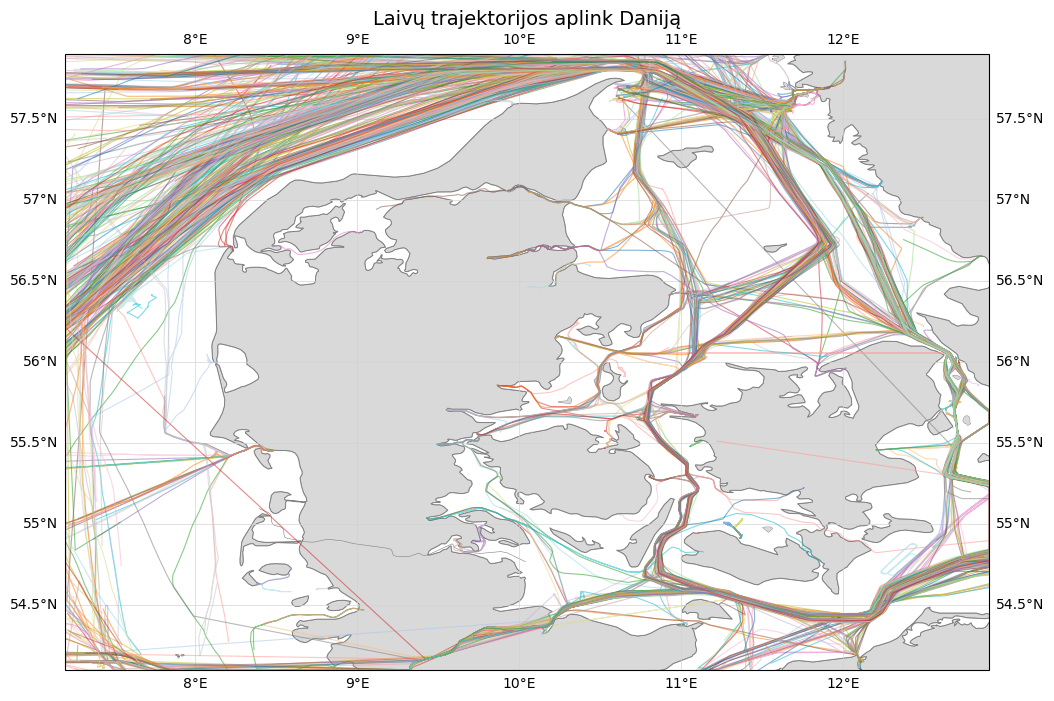

In [72]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 1. Pasirenkam regioną aplink Daniją
lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

# 2. Pasiliekam tik taškus tame regione
df_plot = df_ship[
    df_ship['longitude'].between(lon_min, lon_max) &
    df_ship['latitude'].between(lat_min, lat_max)
].copy()

# 3. Dėl greičio galima praretinti taškus
#    Pvz. kas 5-as taškas kiekvienam laivui
# df_plot = (
#     df_plot
#     .sort_values(['mmsi', 'timestamp'])
#     .groupby('mmsi', group_keys=False)
#     .apply(lambda g: g.iloc[::5])
#     .reset_index(drop=True)
# )

# 4. Braižymas
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Fonas
ax.set_facecolor('#f2f2f2')
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

# Tinklelis ir geografinės etiketės
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='lightgray',
    alpha=0.8,
    linestyle='-'
)
gl.top_labels = True
gl.right_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Spalvos trajektorijoms
cmap = plt.cm.tab20
mmsi_list = df_plot['mmsi'].drop_duplicates().tolist()

for i, mmsi in enumerate(mmsi_list):
    g = df_plot[df_plot['mmsi'] == mmsi]
    ax.plot(
        g['longitude'].values,
        g['latitude'].values,
        transform=ccrs.PlateCarree(),
        linewidth=0.8,
        alpha=0.55,
        color=cmap(i % 20)
    )

plt.title('Laivų trajektorijos aplink Daniją', fontsize=14)
plt.show()

In [73]:
df_plot['mmsi'].nunique()

910

In [74]:
numeric_cols = df_ship.select_dtypes(include='number')
print(numeric_cols.corr(method='pearson'))

                   mmsi  latitude  longitude       rot       sog       cog  \
mmsi           1.000000  0.016461  -0.046723 -0.000681  0.149333 -0.064800   
latitude       0.016461  1.000000  -0.206632  0.000405  0.004193  0.071723   
longitude     -0.046723 -0.206632   1.000000  0.000910  0.040218  0.085149   
rot           -0.000681  0.000405   0.000910  1.000000 -0.001385  0.000375   
sog            0.149333  0.004193   0.040218 -0.001385  1.000000 -0.066324   
cog           -0.064800  0.071723   0.085149  0.000375 -0.066324  1.000000   
heading       -0.057007  0.078140   0.084594 -0.000370 -0.008675  0.866649   
width          0.495740  0.011551  -0.074413 -0.000534  0.418878 -0.070274   
length         0.477018 -0.008974  -0.061145 -0.000592  0.500254 -0.079314   
draught        0.481275 -0.000134  -0.042418 -0.000787  0.368715  0.002168   
a              0.484642  0.039615  -0.004240 -0.000397  0.413987 -0.062779   
b              0.105429 -0.068989  -0.092074 -0.000389  0.238399

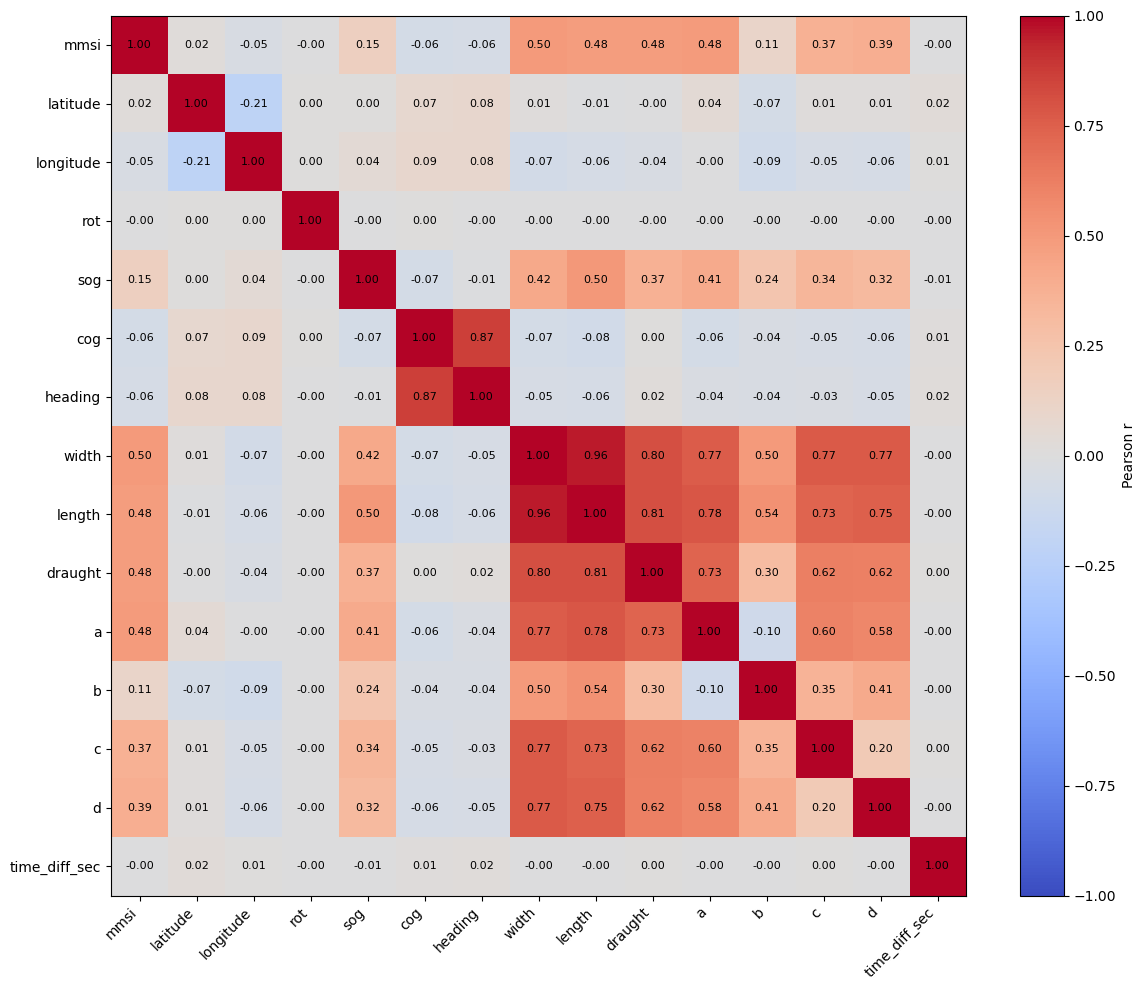

In [75]:
numeric_cols = df_ship.select_dtypes(include="number")
corr_matrix = numeric_cols.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

In [76]:
df_ship = df_ship[['timestamp', 'mmsi', 'latitude', 'longitude']].copy()


In [77]:
df.groupby("ship_type").size()

ship_type
cargo     9100716
tanker    3266406
dtype: int64

In [78]:
# -----------------------------
# PARAMETERS
# -----------------------------
RESAMPLE_FREQ = '2min'
MAX_GAP = 3600  # 1 hour

# -----------------------------
# 1. SORT DATA
# -----------------------------
df = df_ship.sort_values(['mmsi', 'timestamp']).copy()

# -----------------------------
# 2. COMPUTE TIME GAPS
# -----------------------------
df['time_gap_sec'] = (
    df.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

# remove entire vessels if any gap is > 1 hour
bad_mmsi = df.loc[df['time_gap_sec'] > MAX_GAP, 'mmsi'].unique()
df = df[~df['mmsi'].isin(bad_mmsi)].copy()

# -----------------------------
# 3. RESAMPLING FUNCTION
# -----------------------------
# -----------------------------
# 3. RESAMPLING FUNCTION
# -----------------------------
def resample_ship(group, mmsi):
    if len(group) < 2:
        return None

    group = (
        group.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
    )

    if group.index.min() == group.index.max():
        return None

    grid = pd.date_range(
        start=group.index.min().ceil(RESAMPLE_FREQ),
        end=group.index.max().floor(RESAMPLE_FREQ),
        freq=RESAMPLE_FREQ
    )

    if len(grid) == 0:
        return None

    tmp = group.reindex(group.index.union(grid)).sort_index()

    tmp[['latitude', 'longitude']] = (
        tmp[['latitude', 'longitude']]
        .interpolate(method='time', limit_area='inside')
    )

    tmp = tmp.loc[grid, ['latitude', 'longitude']].reset_index()
    tmp = tmp.rename(columns={'index': 'timestamp'})
    tmp['mmsi'] = mmsi

    return tmp[['timestamp', 'mmsi', 'latitude', 'longitude']]


# -----------------------------
# 4. APPLY
# -----------------------------
parts = []

for mmsi, group in df.groupby('mmsi'):
    res = resample_ship(group, mmsi)
    if res is not None and not res.empty:
        parts.append(res)

df_resampled = pd.concat(parts, ignore_index=True)

# -----------------------------
# RESULT
# -----------------------------
df_resampled.head()

,timestamp,mmsi,latitude,longitude
0,2025-05-16 21:26:00,205136000,55.109762,5.760468
1,2025-05-16 21:28:00,205136000,55.114330,5.763744
2,2025-05-16 21:30:00,205136000,55.118906,5.766995
3,2025-05-16 21:32:00,205136000,55.123357,5.770215
4,2025-05-16 21:34:00,205136000,55.127937,5.773454


In [79]:
df_resampled['mmsi'].nunique()

685

In [80]:
df_ship['timestamp'].unique()

<DatetimeArray>
['2025-05-16 21:25:56', '2025-05-16 21:26:56', '2025-05-16 21:27:16',
 '2025-05-16 21:27:45', '2025-05-16 21:27:56', '2025-05-16 21:28:16',
 '2025-05-16 21:28:45', '2025-05-16 21:29:25', '2025-05-16 21:29:55',
 '2025-05-16 21:30:25',
 ...
 '2025-05-16 09:23:03', '2025-05-16 09:24:03', '2025-05-16 09:23:49',
 '2025-05-17 00:00:17', '2025-05-16 16:46:09', '2025-05-18 00:00:36',
 '2025-05-17 00:00:16', '2025-05-15 00:00:10', '2025-05-17 00:00:03',
 '2025-05-17 00:00:09']
Length: 345391, dtype: datetime64[ns]

----------------


In [81]:
# TRAJECTORY WINDOWS / SEQUENCES

WINDOW_SIZE = 20
STEP_SIZE = 10   # 50% overlap

# tik dėl saugumo
df_seq_src = (
    df_resampled[['timestamp', 'mmsi', 'latitude', 'longitude']]
    .sort_values(['mmsi', 'timestamp'])
    .reset_index(drop=True)
    .copy()
)

sequence_metadata = []
sequence_arrays = []
original_sequences = []

sequence_id = 0

for mmsi, group in df_seq_src.groupby('mmsi'):
    group = group.sort_values('timestamp').reset_index(drop=True)

    n = len(group)
    if n < WINDOW_SIZE:
        continue

    for start_idx in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end_idx = start_idx + WINDOW_SIZE

        window = group.iloc[start_idx:end_idx].copy()

        # 20x2 masyvas DTW etapui
        coords = window[['latitude', 'longitude']].to_numpy()

        start=coords[0]
        cords_relative = coords - start
        sequence_arrays.append(cords_relative)
        original_sequences.append(coords)

        sequence_metadata.append({
            'sequence_id': sequence_id,
            'mmsi': mmsi,
            'start_time': window['timestamp'].iloc[0],
            'end_time': window['timestamp'].iloc[-1],
            'window_start_idx': start_idx,
            'window_end_idx': end_idx - 1
        })

        sequence_id += 1

# metadata lentelė
sequence_metadata_df = pd.DataFrame(sequence_metadata)

print("Sekų skaičius:", len(sequence_arrays))
print("Metadata shape:", sequence_metadata_df.shape)
sequence_metadata_df.head()

Sekų skaičius: 60180
Metadata shape: (60180, 6)


,sequence_id,mmsi,start_time,end_time,window_start_idx,window_end_idx
0,0,205136000,2025-05-16 21:26:00,2025-05-16 22:04:00,0,19
1,1,205136000,2025-05-16 21:46:00,2025-05-16 22:24:00,10,29
2,2,205136000,2025-05-16 22:06:00,2025-05-16 22:44:00,20,39
3,3,205136000,2025-05-16 22:26:00,2025-05-16 23:04:00,30,49
4,4,205136000,2025-05-16 22:46:00,2025-05-16 23:24:00,40,59


In [82]:
# pirma seka
print(sequence_metadata_df.iloc[0])
print(sequence_arrays[0].shape)   # turėtų būti (20, 2)
print(sequence_arrays[0])

sequence_id                           0
mmsi                          205136000
start_time          2025-05-16 21:26:00
end_time            2025-05-16 22:04:00
window_start_idx                      0
window_end_idx                       19
Name: 0, dtype: object
(20, 2)
[[0.         0.        ]
 [0.00456867 0.0032762 ]
 [0.0091448  0.00652687]
 [0.01359587 0.0097468 ]
 [0.01817547 0.0129857 ]
 [0.02283569 0.01635653]
 [0.02743147 0.0196292 ]
 [0.03196377 0.02290235]
 [0.0365407  0.02621523]
 [0.0411013  0.02952003]
 [0.04569497 0.0328322 ]
 [0.05023847 0.0361062 ]
 [0.05486997 0.0394497 ]
 [0.05951047 0.0427597 ]
 [0.06414772 0.04603402]
 [0.06872787 0.0486615 ]
 [0.07343522 0.05142333]
 [0.07816597 0.0541567 ]
 [0.0829198  0.05691609]
 [0.0877626  0.0597092 ]]


In [83]:
sequence_metadata_df.groupby('mmsi').size().sort_values(ascending=False).head(10)

mmsi
677064088    286
219019354    286
219355000    286
219329000    286
211138490    286
265581970    286
275511000    286
211223310    286
275519000    286
211341960    286
dtype: int64

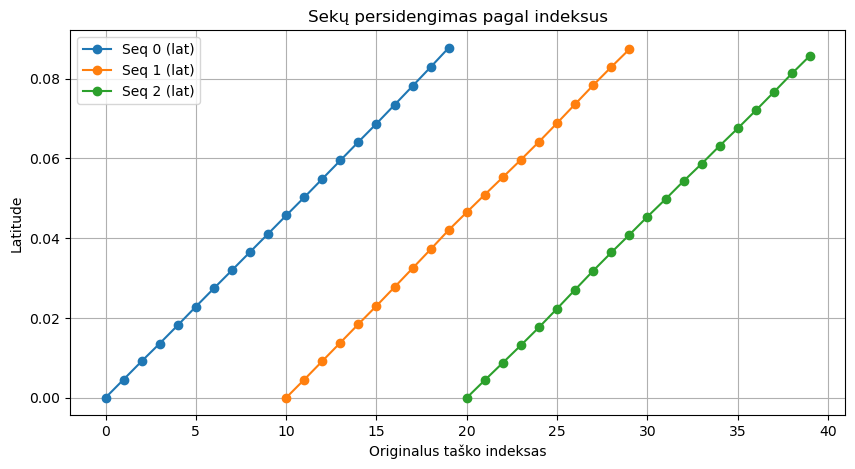

In [84]:
seq_ids = [0, 1, 2]

plt.figure(figsize=(10, 5))

for seq_id in seq_ids:
    coords = sequence_arrays[seq_id]
    start = sequence_metadata_df.iloc[seq_id]["window_start_idx"]
    x = np.arange(start, start + len(coords))

    plt.plot(x, coords[:, 0], marker='o', label=f'Seq {seq_id} (lat)')
    
plt.xlabel("Originalus taško indeksas")
plt.ylabel("Latitude")
plt.title("Sekų persidengimas pagal indeksus")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
# kiek sekų turi kiekvienas laivas visame rinkinyje
all_vessel_seq_counts = sequence_metadata_df.groupby('mmsi').size()

# dažnių lentelė visam rinkiniui
all_freq_table = (
    all_vessel_seq_counts
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)

all_freq_table.columns = ['n_sequences', 'n_vessels']
all_freq_table

,n_sequences,n_vessels
0,286,56
1,283,2
2,280,1
3,277,1
4,276,1
...,...,...
196,5,11
197,4,12
198,3,14
199,2,23


In [86]:
all_vessel_seq_counts.describe()

count    642.000000
mean      93.738318
std       87.926203
min        1.000000
25%       16.250000
50%       70.000000
75%      141.750000
max      286.000000
dtype: float64

In [87]:
# FILTER VESSELS WITH AT LEAST 15 SEQUENCES

MIN_SEQUENCES = 15

vessel_seq_counts_all = sequence_metadata_df.groupby('mmsi').size()

valid_mmsi = vessel_seq_counts_all[vessel_seq_counts_all >= MIN_SEQUENCES].index

filtered_metadata_df = (
    sequence_metadata_df[sequence_metadata_df['mmsi'].isin(valid_mmsi)]
    .sort_values(['mmsi', 'sequence_id'])
    .reset_index(drop=True)
    .copy()
)

filtered_sequence_ids = filtered_metadata_df['sequence_id'].tolist()
filtered_sequence_arrays = [sequence_arrays[i] for i in filtered_sequence_ids]
filtered_sequence_arrays_original = [original_sequences[i] for i in filtered_sequence_ids]

print("Laivų prieš filtrą:", sequence_metadata_df['mmsi'].nunique())
print("Laivų po filtro:", filtered_metadata_df['mmsi'].nunique())
print("Sekų prieš filtrą:", len(sequence_arrays))
print("Sekų po filtro:", len(filtered_sequence_arrays))


Laivų prieš filtrą: 642
Laivų po filtro: 493
Sekų prieš filtrą: 60180
Sekų po filtro: 59294


In [88]:
filtered_metadata_df.groupby('mmsi').size().describe()

count    493.000000
mean     120.271805
std       83.828483
min       15.000000
25%       53.000000
50%       98.000000
75%      164.000000
max      286.000000
dtype: float64

In [89]:
from tslearn.clustering import TimeSeriesKMeans


In [100]:
model = TimeSeriesKMeans(n_clusters=30, metric="dtw",
                         max_iter=10, random_state=5)

klasteriai=model.fit_predict(filtered_sequence_arrays)

In [101]:
print(filtered_metadata_df.shape)
print(klasteriai.shape)
print(np.unique(klasteriai, return_counts=True))
X = np.array(filtered_sequence_arrays)
print("lat min/max:", np.nanmin(X[:, :, 0]), np.nanmax(X[:, :, 0]))
print("lon min/max:", np.nanmin(X[:, :, 1]), np.nanmax(X[:, :, 1]))

print("pirma trajektorija:")
print(X[0][:5])

(59294, 6)
(59294,)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), array([ 2290, 23241,   863,  2308,   590,  1500,   586,  1983,   899,
           2,  2691,  1262,  1551,  1743,  1413,   807,  1082,     2,
        2828,   841,  1707,  1215,  1041,   682,   522,  1657,   634,
        1650,   827,   877]))
lat min/max: -0.8931682499999951 0.19399333333333146
lon min/max: -7.740918300000001 3.7164557499999997
pirma trajektorija:
[[0.         0.        ]
 [0.00456867 0.0032762 ]
 [0.0091448  0.00652687]
 [0.01359587 0.0097468 ]
 [0.01817547 0.0129857 ]]


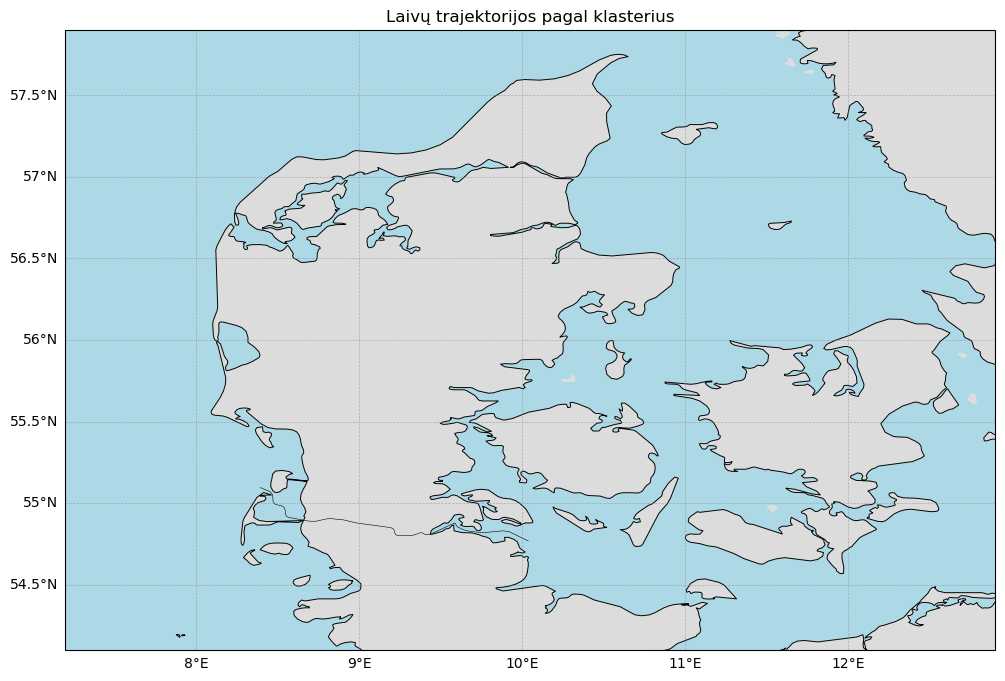

In [102]:
labels = np.array(klasteriai)

lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

for i in range(len(X)):
    lat = X[i, :, 0]
    lon = X[i, :, 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    ax.plot(
        lon[valid],
        lat[valid],
        color=plt.cm.tab20(int(labels[i]) % 20),
        alpha=0.6,
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Laivų trajektorijos pagal klasterius")
plt.show()

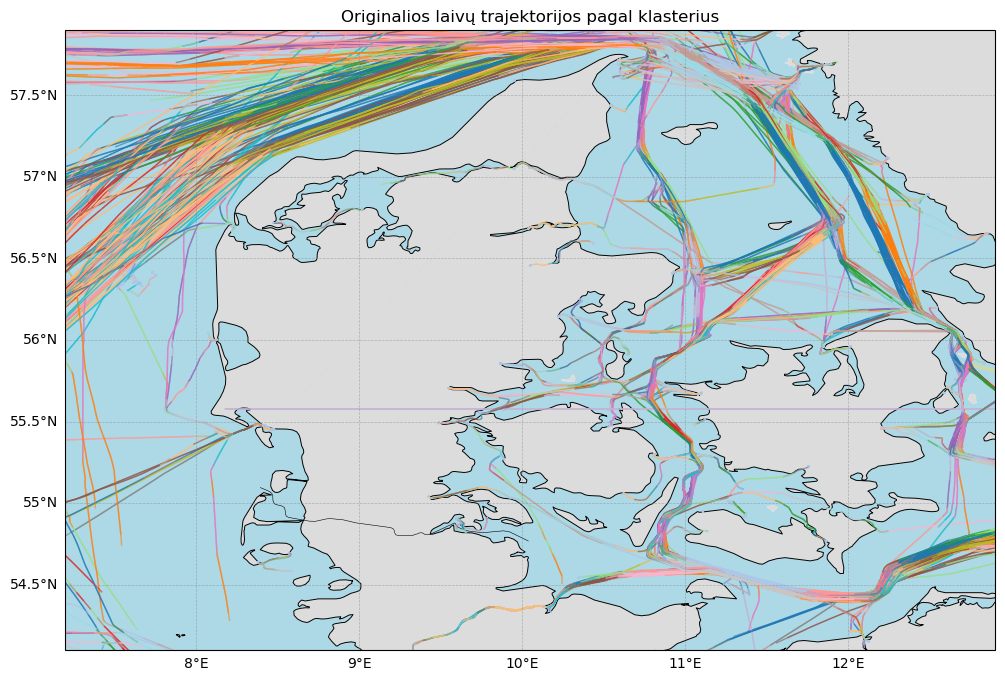

In [103]:

labels = np.array(klasteriai)             # klasteriai iš reliatyvių sekų
X = np.array(filtered_sequence_arrays_original)  # originalios lat/lon sekos

lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

for i in range(len(X)):
    lat = X[i, :, 0]
    lon = X[i, :, 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    ax.plot(
        lon[valid],
        lat[valid],
        color=plt.cm.tab20(int(labels[i]) % 20),
        alpha=0.6,
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Originalios laivų trajektorijos pagal klasterius")
plt.show()

In [104]:
print("len(labels):", len(labels))
print("len(X):", len(X))
print("labels shape:", labels.shape)
print("X shape:", X.shape)

len(labels): 59294
len(X): 59294
labels shape: (59294,)
X shape: (59294, 20, 2)


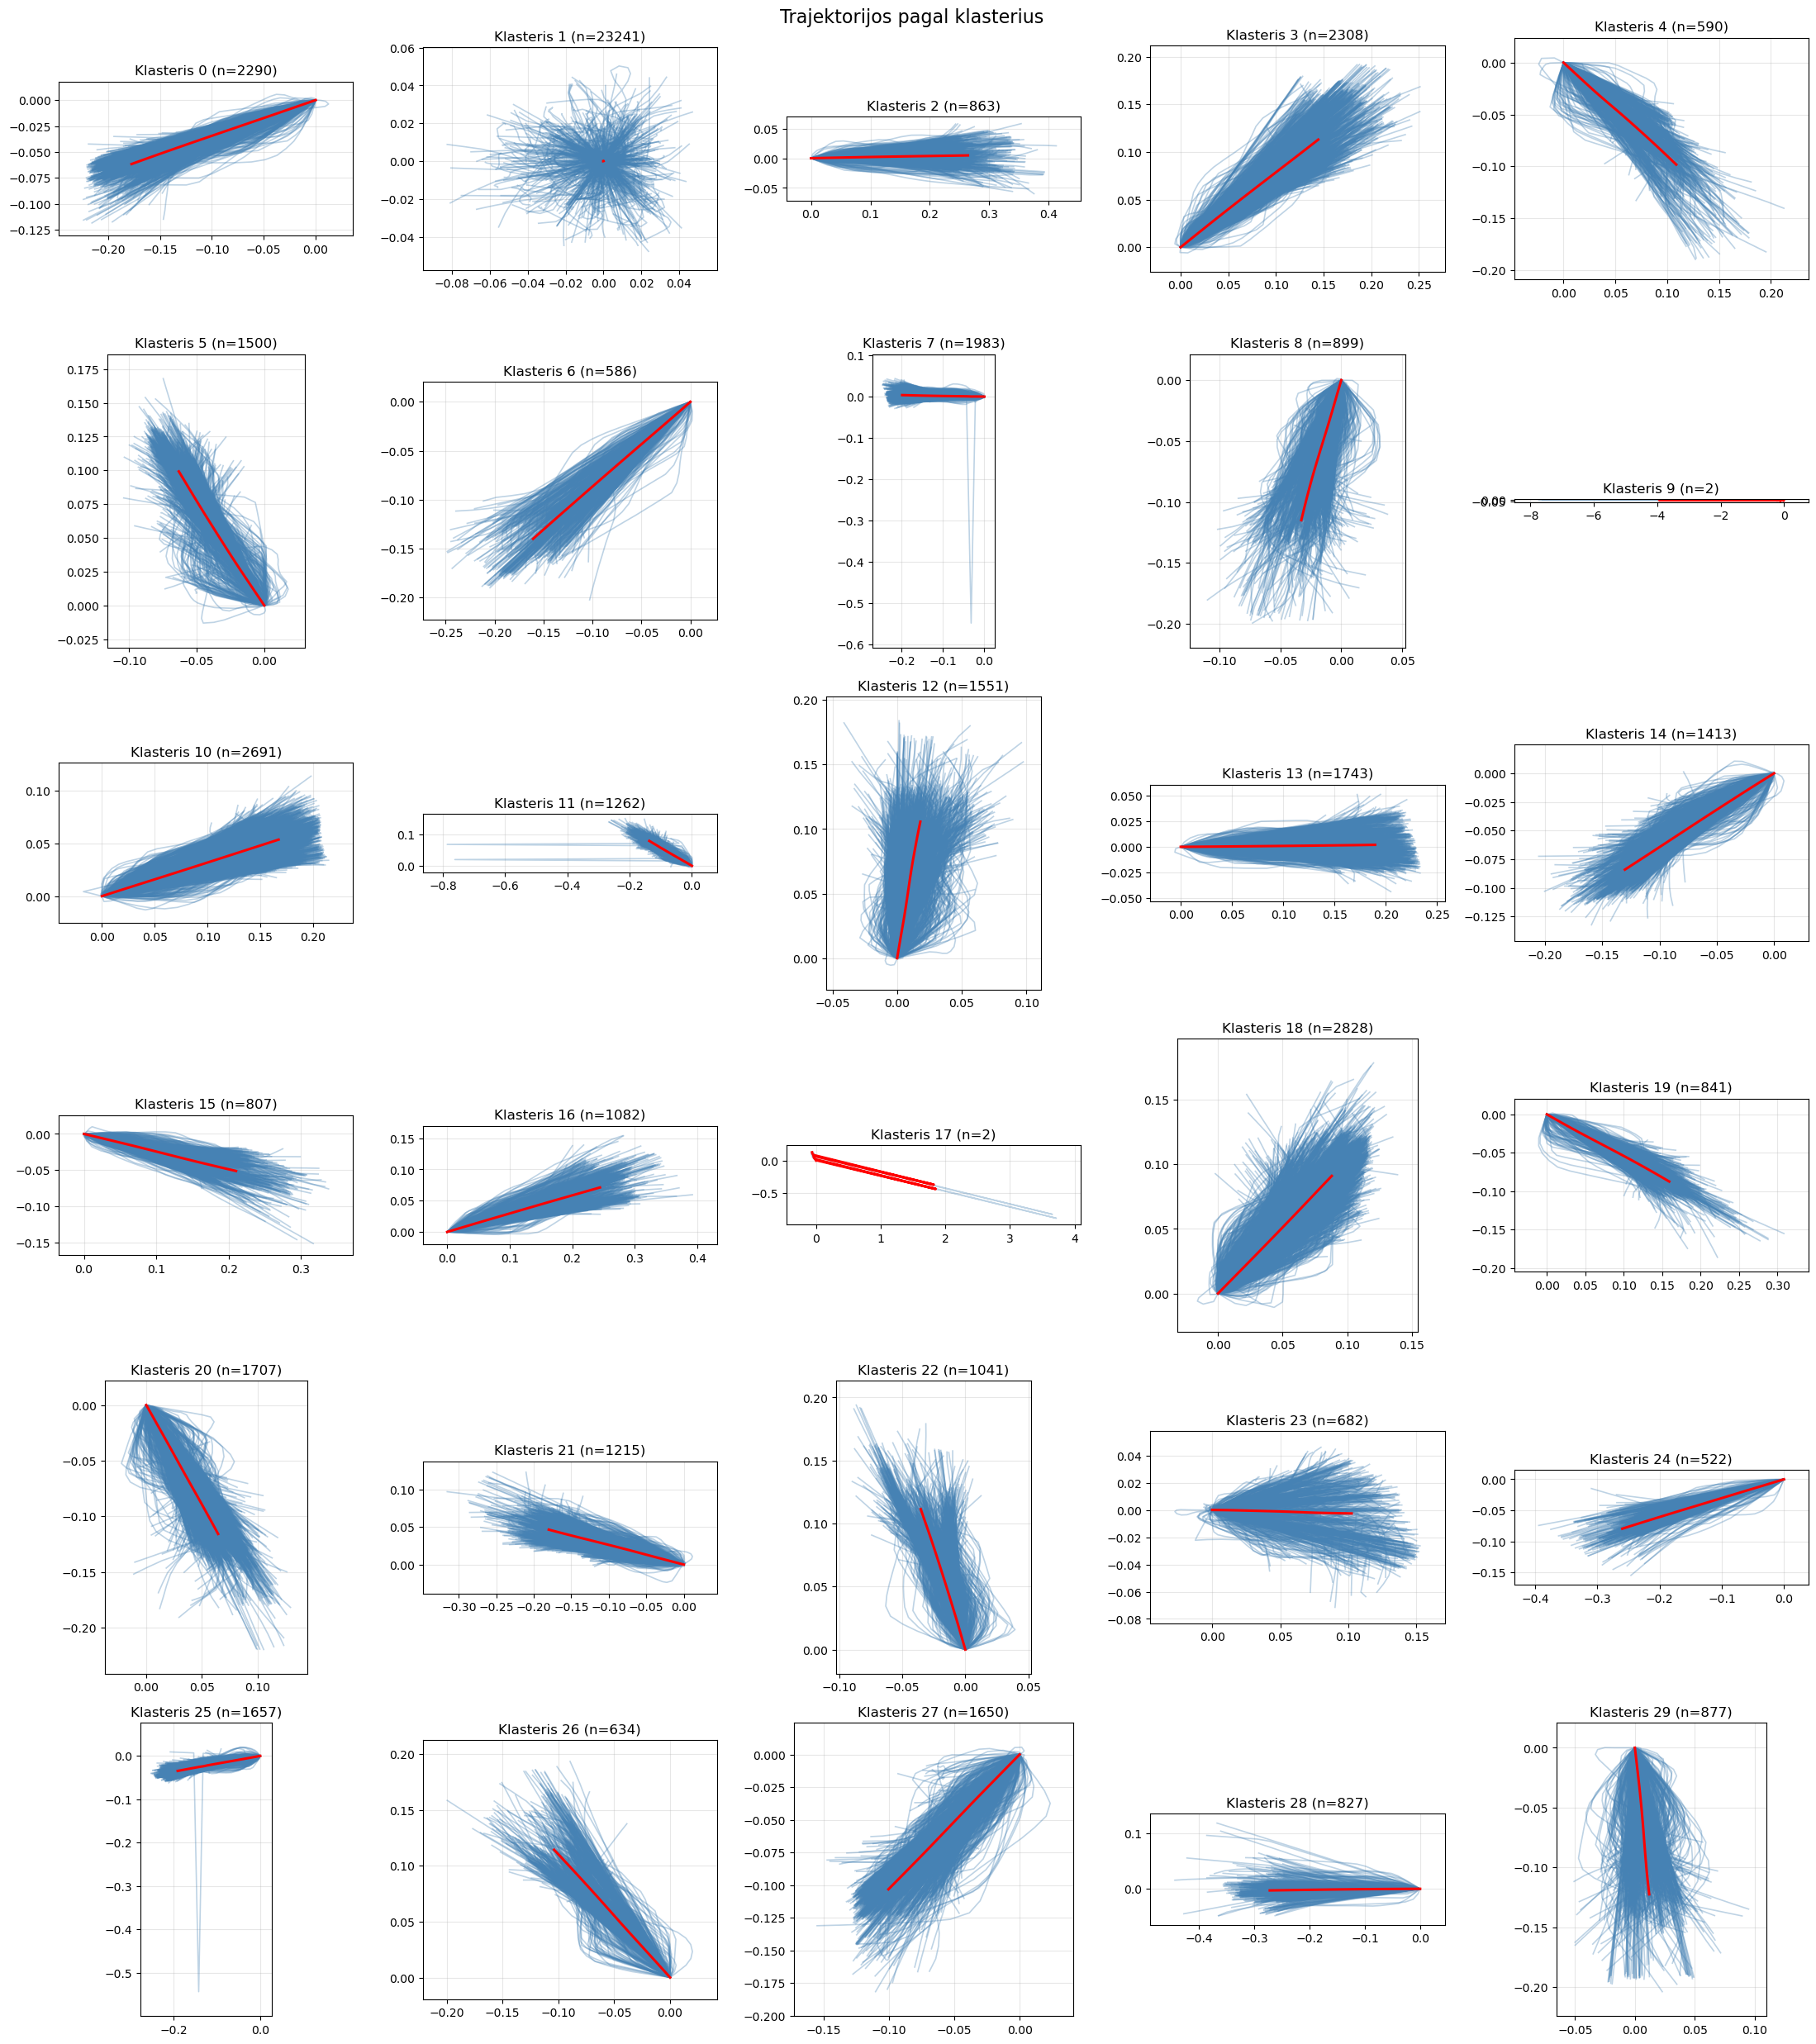

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import math

X = np.array(filtered_sequence_arrays)
labels = np.array(klasteriai)

n_clusters = len(np.unique(labels))
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for k in range(n_clusters):
    ax = axes[k]
    idx = np.where(labels == k)[0]

    all_lon = []
    all_lat = []

    for i in idx:
        coords = X[i]
        lat = coords[:, 0]
        lon = coords[:, 1]
        valid = np.isfinite(lat) & np.isfinite(lon)

        if valid.any():
            ax.plot(lon[valid], lat[valid], color='steelblue', alpha=0.35, linewidth=1.2)
            all_lon.extend(lon[valid])
            all_lat.extend(lat[valid])

    if len(idx) > 0:
        mean_traj = np.nanmean(X[idx], axis=0)
        valid_mean = np.isfinite(mean_traj[:, 0]) & np.isfinite(mean_traj[:, 1])
        ax.plot(mean_traj[valid_mean, 1], mean_traj[valid_mean, 0], color='red', linewidth=2.2)

    if len(all_lon) > 0 and len(all_lat) > 0:
        xmin, xmax = np.min(all_lon), np.max(all_lon)
        ymin, ymax = np.min(all_lat), np.max(all_lat)

        xpad = max((xmax - xmin) * 0.1, 0.001)
        ypad = max((ymax - ymin) * 0.1, 0.001)

        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f'Klasteris {k} (n={len(idx)})')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Trajektorijos pagal klasterius', fontsize=16)
plt.tight_layout()
plt.show()

In [106]:
print(df.columns.tolist())

['timestamp', 'mmsi', 'latitude', 'longitude', 'time_gap_sec']


In [107]:
print(filtered_metadata_df.columns.tolist())

['sequence_id', 'mmsi', 'start_time', 'end_time', 'window_start_idx', 'window_end_idx']


In [110]:
cluster_id = 17

idx = np.where(labels == cluster_id)[0]

print(f"Klasteris {cluster_id}, sekų skaičius: {len(idx)}")

for i in idx:
    row = filtered_metadata_df.iloc[i]
    print(f"\n--- X indeksas: {i} ---")
    print(f"sequence_id: {row['sequence_id']}")
    print(f"MMSI: {row['mmsi']}")
    print(f"start: {row['start_time']}")
    print(f"end: {row['end_time']}")
    print("Trajektorijos taškai (lat, lon):")
    print(X[i])

Klasteris 17, sekų skaičius: 2

--- X indeksas: 26028 ---
sequence_id: 26431
MMSI: 249223000
start: 2025-05-17 02:48:00
end: 2025-05-17 03:26:00
Trajektorijos taškai (lat, lon):
[[ 0.          0.        ]
 [ 0.00590178 -0.006767  ]
 [ 0.01179811 -0.01363578]
 [ 0.01768389 -0.02053578]
 [ 0.02350051 -0.02748281]
 [ 0.02928378 -0.03442044]
 [ 0.0350624  -0.04133657]
 [ 0.04083378 -0.04826599]
 [ 0.04669378 -0.05460344]
 [ 0.05339378 -0.05769444]
 [ 0.06021028 -0.06037794]
 [ 0.06705228 -0.06303194]
 [-0.83295797  3.65607781]
 [ 0.08082728 -0.06837794]
 [ 0.08776405 -0.07106481]
 [ 0.09474032 -0.07377354]
 [ 0.10176858 -0.07644164]
 [ 0.10879378 -0.07751994]
 [ 0.11584467 -0.07619644]
 [ 0.12286489 -0.07453756]]

--- X indeksas: 26029 ---
sequence_id: 26432
MMSI: 249223000
start: 2025-05-17 03:08:00
end: 2025-05-17 03:46:00
Trajektorijos taškai (lat, lon):
[[ 0.00000000e+00  0.00000000e+00]
 [ 6.84200000e-03 -2.65400000e-03]
 [-8.93168250e-01  3.71645575e+00]
 [ 2.06170000e-02 -8.00000000

In [111]:
traj = X[23360]

dlat = np.diff(traj[:, 0])
dlon = np.diff(traj[:, 1])

print("dlat:")
print(dlat)
print("dlon:")
print(dlon)

print("max |dlat| =", np.max(np.abs(dlat)))
print("max |dlon| =", np.max(np.abs(dlon)))

dlat:
[-0.0042569  -0.00476162 -0.00456845 -0.00453618 -0.0045046  -0.0045081
 -0.00450114 -0.00458238 -0.00451801 -0.00452351 -0.00450686 -0.00450317
 -0.00449307 -0.00444433 -0.0045072  -0.00454863 -0.00459604 -0.00461236
 -0.0046106 ]
dlon:
[-0.00616307 -0.00680073 -0.00649405 -0.0065448  -0.00628    -0.00642692
 -0.00653917 -0.00648462 -0.00644844 -0.00647302 -0.00651543 -0.0064036
 -0.0063359  -0.00629793 -0.00648483 -0.00655293 -0.00661811 -0.00663129
 -0.0066712 ]
max |dlat| = 0.004761616883115494
max |dlon| = 0.006800725108226047
